Using run_id from /Users/lshriver/PycharmProjects/lf-pinn-inverse-schrodinger/data/run_id.txt: 20260815_131639_628672
Loaded 6000 epochs of metrics.


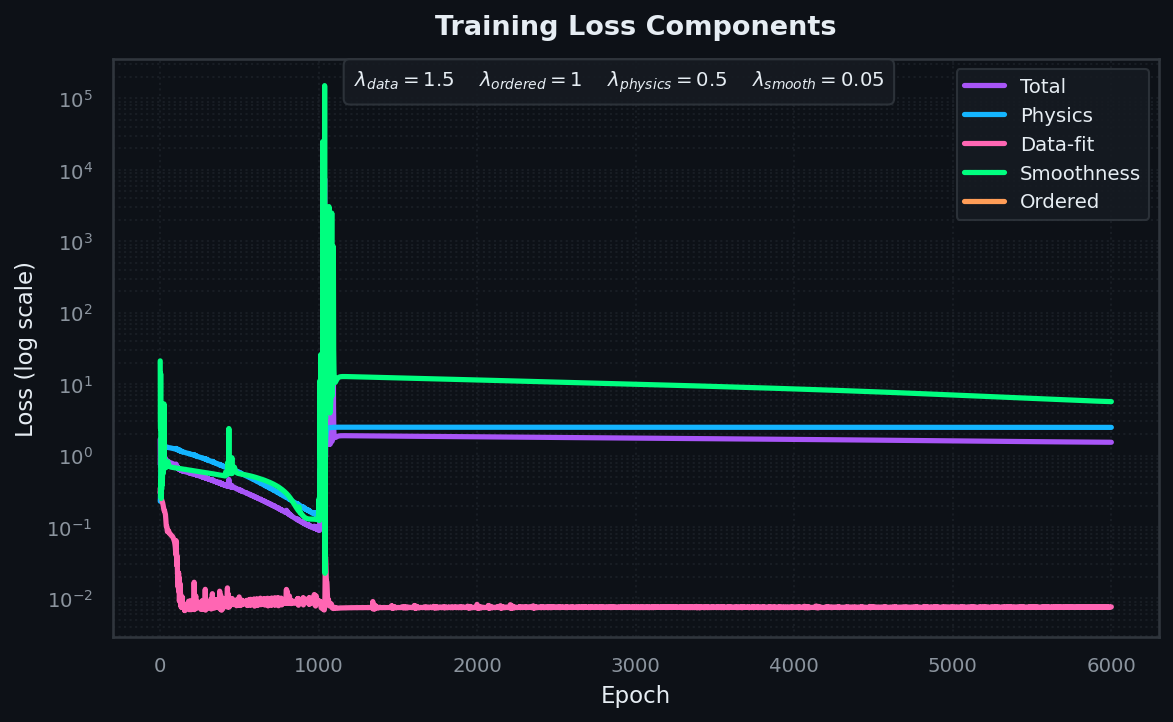

In [1]:
import sys
from pathlib import Path
import json
import sqlite3

# Add project root
PROJECT_ROOT = Path("..").resolve()


import pandas as pd
import matplotlib.pyplot as plt

from visualizations import (
    plot_loss_history,
    plot_potential,
    plot_wavefunctions,
    plot_energy_spectrum,
    plot_pod_singular_values
)

DATA_DIR = PROJECT_ROOT / "data"
DB_PATH = DATA_DIR / "training_runs.db"

# Try to load the latest run_id if available, otherwise use a default or specified one
run_id = "20260425_085631_749744" # Default
run_id_file = DATA_DIR / "run_id.txt"
if run_id_file.exists():
    run_id = run_id_file.read_text().strip()
    print(f"Using run_id from {run_id_file}: {run_id}")
else:
    print(f"Using default/specified run_id: {run_id}")

RUN_ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / "runs" / run_id

conn = sqlite3.connect(DB_PATH)
conn.row_factory = sqlite3.Row

run_row = conn.execute(
    "SELECT * FROM runs WHERE run_id = ?",
    (run_id,),
).fetchone()

if run_row is None:
    raise KeyError(f"Run not found: {run_id}")

metrics_df = pd.read_sql_query(
    """
    SELECT epoch, total_loss, physics_loss, data_loss, smooth_loss, ordered_loss
    FROM metrics
    WHERE run_id = ?
    ORDER BY epoch ASC
    """,
    conn,
    params=(run_id,),
)

print(f"Loaded {len(metrics_df)} epochs of metrics.")
metrics_df.head()

run_meta = dict(run_row)
hyperparams = json.loads(run_meta["hyperparams"])

# Plot loss history
fig_loss = plot_loss_history(
    epochs=metrics_df["epoch"].values,
    total=metrics_df["total_loss"].values,
    physics=metrics_df["physics_loss"].values,
    data=metrics_df["data_loss"].values,
    smooth=metrics_df["smooth_loss"].values,
    ordered=metrics_df["ordered_loss"].values,
    lambdas=hyperparams["lambdas"]
)
plt.show()

In [2]:
# ... imports ...
from db_logger import RunLogger

# ... setup ...
logger = RunLogger(DB_PATH)

# ... run_id logic ...

# Get data directly as a DataFrame
try:
    run_data = logger.get_run_data(run_id, as_dataframe=True)
except KeyError:
    raise KeyError(f"Run not found: {run_id}")

# No need for pd.DataFrame(metrics_list) anymore!
run_meta = run_data["run"]
metrics_df = run_data["metrics"]  # Already a DataFrame

print(f"Loaded {len(metrics_df)} epochs of metrics.")
metrics_df.head()

hyperparams = json.loads(run_meta["hyperparams"])

# ... plotting code ...

Loaded 6000 epochs of metrics.


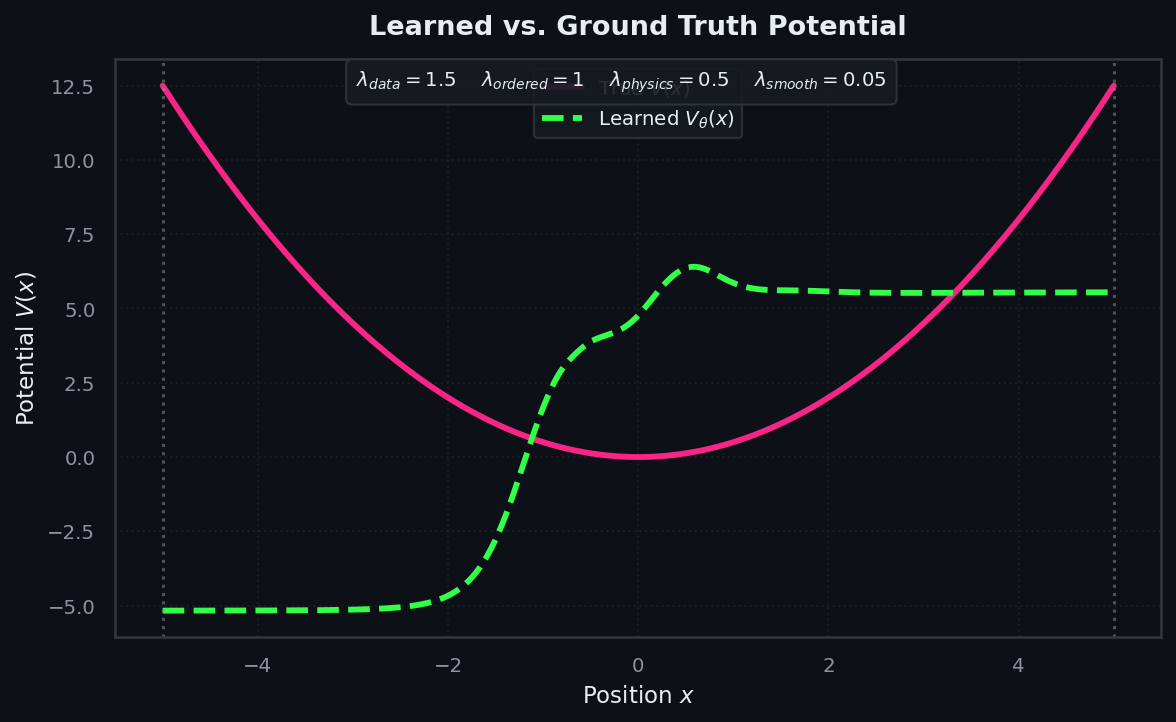

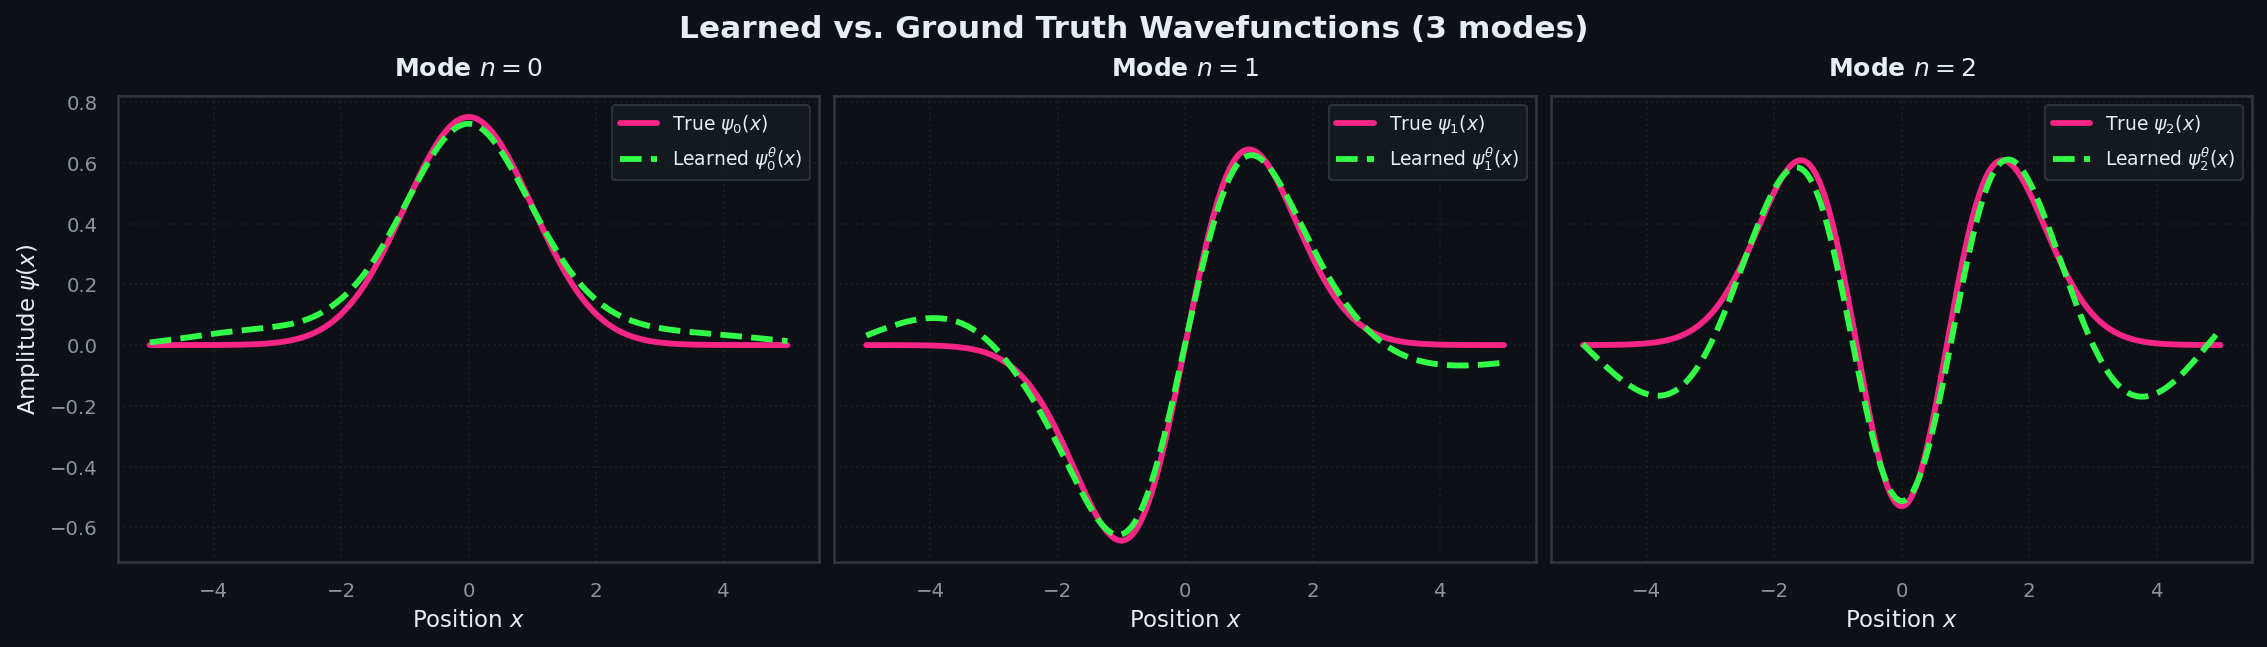

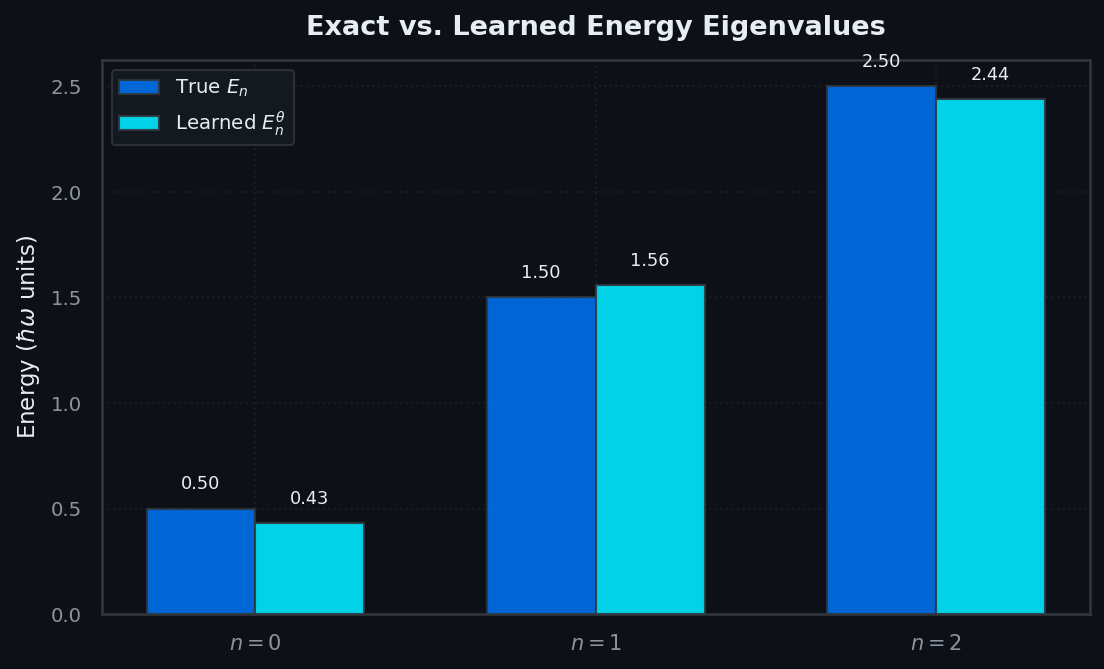


Singular Values:
------------------------------
  Mode (k) |         Sigma_k
------------------------------
         1 |    1.000000e+00
         2 |    1.000000e+00
         3 |    9.999999e-01
------------------------------


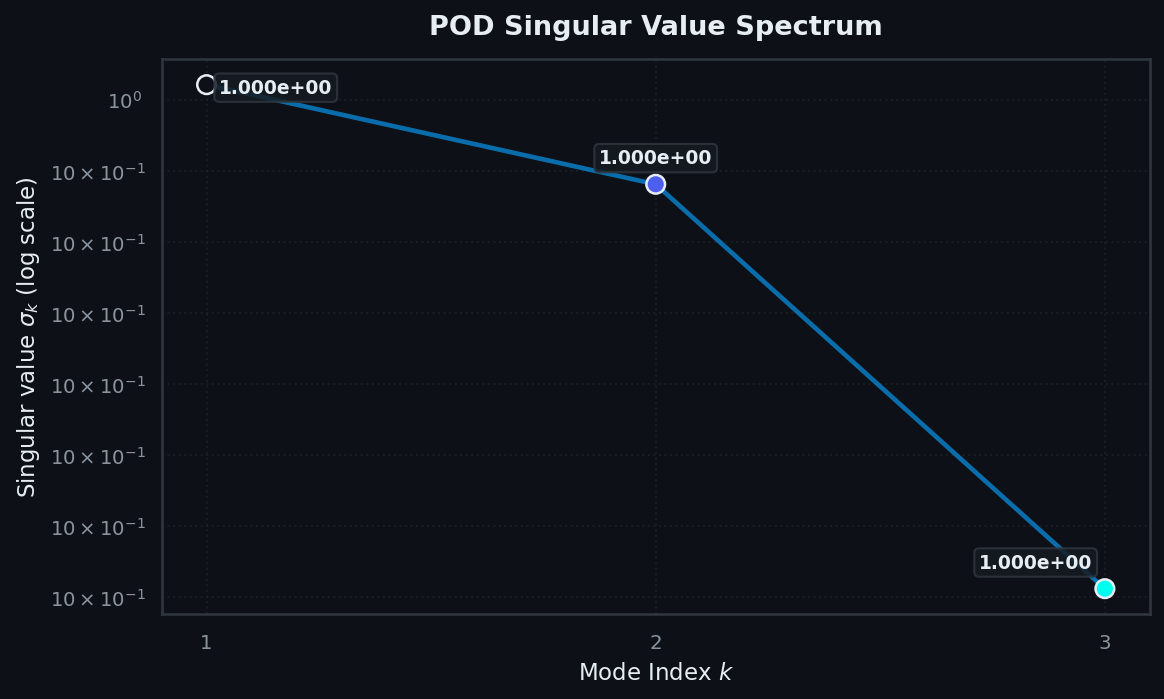

In [3]:
import numpy as np
import torch

# Load artifacts
diagnostics = np.load(RUN_ARTIFACTS_DIR / "diagnostics.npz")
ground_truth = torch.load(RUN_ARTIFACTS_DIR / "ground_truth.pt")

x = ground_truth['x']
V_true = ground_truth['V_true']
psi_true = ground_truth['psi_true']
E_true = ground_truth['E_true']

V_learned = torch.from_numpy(diagnostics['V_learned'])
psi_learned = [torch.from_numpy(p) for p in diagnostics['psi_learned']]
E_learned = torch.from_numpy(diagnostics['E_learned'])
pod_singular_values = torch.from_numpy(diagnostics['pod_singular_values'])

# Visualization 1: Potential
plot_potential(x, V_true, V_learned, hyperparams['lambdas'])
plt.show()

# Visualization 2: Wavefunctions
plot_wavefunctions(x, psi_true, psi_learned)
plt.show()

# Visualization 3: Energy Spectrum
plot_energy_spectrum(E_true, E_learned)
plt.show()

# Visualization 4: POD Singular Values
plot_pod_singular_values(pod_singular_values)
plt.show()

In [4]:
from pathlib import Path
from db_logger import RunLogger
from IPython.display import HTML, display

# 1. Setup & Load Data
PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
DB_PATH = DATA_DIR / "training_runs.db"

logger = RunLogger(DB_PATH)
run_id = "20260425_115828_278469"

run_id_file = DATA_DIR / "run_id.txt"
if run_id_file.exists():
    run_id = run_id_file.read_text().strip()

try:
    run_data = logger.get_run_data(run_id, as_dataframe=True)
    metrics_df = run_data["metrics"]
    print(f"✅ Loaded {len(metrics_df)} epochs of metrics.")
except KeyError:
    print(f"❌ Run not found: {run_id}")
    metrics_df = None

# 2. Manual HTML Generation (The Nuclear Option)
if metrics_df is not None:
    # Start HTML
    html = """
    <style>
        @import url('https://fonts.googleapis.com/css2?family=Aclonica&family=Merriweather:wght@300;400;700&family=Fira+Code&display=swap');

        .custom-table {
            width: 100%;
            border-collapse: collapse;
            font-family: -apple-system, 'Aclonica', sans-serif;
            font-size: 13px;
            margin-bottom: 20px;
        }
        .custom-table caption {
            caption-side: top;
            text-align: center;
            font-size: 16px;
            font-weight: bold;
            color: #34495e;
            margin-bottom: 15px;
        }
        .custom-table th {
            background-color: #f8f9fa;
            color: #2c3e50;
            font-weight: 600;
            text-transform: uppercase;
            font-size: 11px;
            letter-spacing: 0.5px;
            padding: 10px;
            border-bottom: 2px solid #00e8ff;
            text-align: right;
        }
        .custom-table td {
            padding: 8px 12px;
            border-bottom: 1px solid #f1f1f1;
            text-align: right;
            color: #9b7dff;
        }
        .custom-table tr:hover {
            background-color: #eef2f7;
        }
        /* Left align the first column (epoch) */
        .custom-table th:first-child, .custom-table td:first-child {
            text-align: left;
        }
    </style>
    <table class="custom-table">
        <caption>📊 Training Run Metrics (6000 Epochs)</caption>
        <thead>
            <tr>
                <th>Epoch</th>
                <th>Total Loss</th>
                <th>Physics Loss</th>
                <th>Data Loss</th>
                <th>Smooth Loss</th>
                <th>Ordered Loss</th>
                <th>Created At</th>
            </tr>
        </thead>
        <tbody>
    """

    # Add rows (Limit to first 100 for performance, or remove limit for all)
    # If you want ALL 6000, remove the [:100] slice, but it might lag
    for _, row in metrics_df.head(100).iterrows():
        html += f"""
        <tr>
            <td>{row['epoch']}</td>
            <td>{row['total_loss']:.6f}</td>
            <td>{row['physics_loss']:.6f}</td>
            <td>{row['data_loss']:.6f}</td>
            <td>{row['smooth_loss']:.6f}</td>
            <td>{row['ordered_loss']:.6f}</td>
            <td style="text-align: left;">{row['created_at']}</td>
        </tr>
        """

    html += """
        </tbody>
    </table>
    <p style="text-align: center; color: #666; font-size: 6px;">
        Showing first 100 rows of 6000. Scroll to see more or export to CSV.
    </p>
    """

    # Force display
    display(HTML(html))
else:
    print("Could not load metrics.")

✅ Loaded 6000 epochs of metrics.


Epoch,Total Loss,Physics Loss,Data Loss,Smooth Loss,Ordered Loss,Created At
1,1.694258,0.229324,0.347705,21.160760,0.000000,2026-08-15T13:16:39.640114+00:00
2,0.738969,0.247825,0.294230,3.474213,0.000000,2026-08-15T13:16:39.648174+00:00
3,0.770760,0.350431,0.317968,2.371870,0.000000,2026-08-15T13:16:39.656203+00:00
4,1.316918,0.433892,0.266773,13.996260,0.000000,2026-08-15T13:16:39.664048+00:00
5,0.689564,0.549566,0.266411,0.303299,0.000000,2026-08-15T13:16:39.671354+00:00
6,0.735503,0.654688,0.263468,0.259137,0.000000,2026-08-15T13:16:39.680013+00:00
7,0.771620,0.746128,0.257370,0.250003,0.000000,2026-08-15T13:16:39.687642+00:00
8,0.802434,0.824770,0.251084,0.268465,0.000000,2026-08-15T13:16:39.696071+00:00
9,0.837789,0.892188,0.245420,0.471303,0.000000,2026-08-15T13:16:39.704286+00:00
10,0.852723,0.950149,0.240579,0.335581,0.000000,2026-08-15T13:16:39.711153+00:00
